# Heave damping gemiddelden en overzichtsplots

Dit notebook gebruikt de Excel-output van `01_calibrate_heave_damping.ipynb`.

Het berekent:

1. het gemiddelde per constructie voor **viscous damping**;
2. het gemiddelde per constructie voor **total damping**, waarbij radiation damping bij de lineaire heave damping wordt opgeteld;
3. het gemiddelde over alle individuele heave-calibraties;
4. twee scatterplots:
   - één met alleen viscous damping;
   - één met total damping inclusief radiation damping.

De kruisjes voor constructiegemiddelden krijgen dezelfde kleur als de individuele tests van die constructie. Het globale gemiddelde is zwart.


In [1]:
# ============================================================
# Imports
# ============================================================
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


In [2]:
# ============================================================
# Input/output paden en plot-instellingen
# ============================================================
# Dit moet hetzelfde pad zijn als de output map uit het heave calibration notebook.
output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2")

# Excelbestand dat door 01_calibrate_heave_damping.ipynb wordt aangemaakt.
heave_excel_path = output_dir / "calibrated_heave_decay_coefficients.xlsx"

# Outputmap voor dit samenvattingsnotebook.
summary_dir = output_dir / "heave_summary"
summary_dir.mkdir(parents=True, exist_ok=True)

summary_excel_path = summary_dir / "heave_damping_summary.xlsx"
viscous_plot_path = summary_dir / "heave_viscous_damping_summary_plot.png"
total_plot_path = summary_dir / "heave_total_damping_summary_plot.png"

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

# Radiation damping map. Voor dit notebook wordt alleen de heave-waarde gebruikt.
rad_damping_map = {
    ("fixedwith", "pitch"): 142.78,
    ("fixedwith", "roll"): 142.78,
    ("fixedwith", "heave"): 3.05,

    ("fixedwithout", "pitch"): 176.24,
    ("fixedwithout", "roll"): 176.24,
    ("fixedwithout", "heave"): 4.00,

    ("spring", "pitch"): 88.35,
    ("spring", "roll"): 82.50,
    ("spring", "heave"): 2.23,
}

print(f"Input Excel: {heave_excel_path}")
print(f"Output map:  {summary_dir}")


Input Excel: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\calibrated_heave_decay_coefficients.xlsx
Output map:  C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\heave_summary


In [3]:
# ============================================================
# Resultaten inlezen en radiation damping toevoegen
# ============================================================
# Het heave notebook schrijft de resultaten naar sheet_name='heave'.
df = pd.read_excel(heave_excel_path, sheet_name="heave")

# Alleen heave meenemen, voor de zekerheid.
if "dof" in df.columns:
    df = df[df["dof"].str.lower() == "heave"].copy()

required_columns = ["construction", "linear_damping", "quadratic_damping"]
missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(
        "Deze kolommen ontbreken in de Excel-output: " + ", ".join(missing)
    )

# Constructienamen normaliseren, zodat de map altijd goed matcht.
df["construction"] = df["construction"].astype(str).str.strip().str.lower()

# Numeriek maken en lege/ongeldige waarden verwijderen.
df["linear_damping"] = pd.to_numeric(df["linear_damping"], errors="coerce")
df["quadratic_damping"] = pd.to_numeric(df["quadratic_damping"], errors="coerce")

df_valid = df.dropna(subset=["construction", "linear_damping", "quadratic_damping"]).copy()

# Radiation damping voor heave toevoegen. Als een waarde ontbreekt, wordt 0 gebruikt.
df_valid["radiation_damping_heave"] = df_valid["construction"].map(
    lambda construction: rad_damping_map.get((construction, "heave"), 0.0)
)

# Total damping: radiation damping wordt bij de lineaire viscous damping opgeteld.
# De kwadratische damping blijft hetzelfde.
df_valid["total_linear_damping"] = df_valid["linear_damping"] + df_valid["radiation_damping_heave"]
df_valid["total_quadratic_damping"] = df_valid["quadratic_damping"]

print(f"Aantal ingelezen heave-resultaten: {len(df)}")
print(f"Aantal geldige heave-resultaten:   {len(df_valid)}")

display_columns = [
    col for col in [
        "construction", "file_name",
        "linear_damping", "quadratic_damping",
        "radiation_damping_heave",
        "total_linear_damping", "total_quadratic_damping",
    ]
    if col in df_valid.columns
]
display(df_valid[display_columns].head(20))


Aantal ingelezen heave-resultaten: 12
Aantal geldige heave-resultaten:   12


,construction,file_name,linear_damping,quadratic_damping,radiation_damping_heave,total_linear_damping,total_quadratic_damping
0,fixedwith,34224_03CB_02_003_007_01_Decay1.h5m,5.50,0.50,3.05,8.55,0.50
1,fixedwith,34224_03CB_02_003_008_01_Decay1.h5m,2.00,4.25,3.05,5.05,4.25
2,fixedwith,34224_03CB_02_003_009_01_Decay1.h5m,4.75,4.00,3.05,7.80,4.00
3,fixedwith,34224_03CB_02_003_010_01_Decay1.h5m,5.50,3.00,3.05,8.55,3.00
4,fixedwithout,34224_03CB_02_004_009_01_Decay1.h5m,2.25,0.50,4.00,6.25,0.50
5,fixedwithout,34224_03CB_02_004_010_01_Decay1.h5m,0.00,2.00,4.00,4.00,2.00
6,fixedwithout,34224_03CB_02_004_011_01_Decay1.h5m,0.00,2.25,4.00,4.00,2.25
7,fixedwithout,34224_03CB_02_004_012_01_Decay1.h5m,1.00,0.75,4.00,5.00,0.75
8,spring,34224_03CB_02_002_006_01_Decay1.h5m,4.50,2.00,2.23,6.73,2.00
9,spring,34224_03CB_02_002_006_01_Decay2.h5m,3.00,3.75,2.23,5.23,3.75


In [4]:
# ============================================================
# Gemiddelde per constructie
# ============================================================
construction_summary = (
    df_valid
    .groupby("construction", as_index=False)
    .agg(
        n=("linear_damping", "size"),

        mean_viscous_linear_damping=("linear_damping", "mean"),
        mean_viscous_quadratic_damping=("quadratic_damping", "mean"),
        std_viscous_linear_damping=("linear_damping", "std"),
        std_viscous_quadratic_damping=("quadratic_damping", "std"),

        radiation_damping_heave=("radiation_damping_heave", "first"),

        mean_total_linear_damping=("total_linear_damping", "mean"),
        mean_total_quadratic_damping=("total_quadratic_damping", "mean"),
        std_total_linear_damping=("total_linear_damping", "std"),
        std_total_quadratic_damping=("total_quadratic_damping", "std"),
    )
    .sort_values("construction")
)

# Backwards-compatible kolomnamen voor eventuele bestaande cellen die je nog gebruikt.
construction_summary["mean_linear_damping"] = construction_summary["mean_viscous_linear_damping"]
construction_summary["mean_quadratic_damping"] = construction_summary["mean_viscous_quadratic_damping"]

display(construction_summary.round(4))


,construction,n,mean_viscous_linear_damping,mean_viscous_quadratic_damping,std_viscous_linear_damping,std_viscous_quadratic_damping,radiation_damping_heave,mean_total_linear_damping,mean_total_quadratic_damping,std_total_linear_damping,std_total_quadratic_damping,mean_linear_damping,mean_quadratic_damping
0,fixedwith,4,4.4375,2.9375,1.6630,1.7124,3.05,7.4875,2.9375,1.6630,1.7124,4.4375,2.9375
1,fixedwithout,4,0.8125,1.3750,1.0680,0.8780,4.00,4.8125,1.3750,1.0680,0.8780,0.8125,1.3750
2,spring,4,4.5625,2.7500,1.8971,1.0206,2.23,6.7925,2.7500,1.8971,1.0206,4.5625,2.7500


In [5]:
# ============================================================
# Gemiddelde van alles
# ============================================================
# 1) Gemiddelde over alle individuele decay-calibraties.
overall_from_all_tests = pd.DataFrame([
    {
        "method": "mean_of_all_individual_tests",
        "n": len(df_valid),
        "viscous_linear_damping": df_valid["linear_damping"].mean(),
        "viscous_quadratic_damping": df_valid["quadratic_damping"].mean(),
        "radiation_damping_heave": df_valid["radiation_damping_heave"].mean(),
        "total_linear_damping": df_valid["total_linear_damping"].mean(),
        "total_quadratic_damping": df_valid["total_quadratic_damping"].mean(),
    }
])

# 2) Gemiddelde van de constructiegemiddelden.
# Dit weegt elke constructie even zwaar, ook als constructies een verschillend aantal tests hebben.
overall_from_construction_means = pd.DataFrame([
    {
        "method": "mean_of_construction_means",
        "n": len(construction_summary),
        "viscous_linear_damping": construction_summary["mean_viscous_linear_damping"].mean(),
        "viscous_quadratic_damping": construction_summary["mean_viscous_quadratic_damping"].mean(),
        "radiation_damping_heave": construction_summary["radiation_damping_heave"].mean(),
        "total_linear_damping": construction_summary["mean_total_linear_damping"].mean(),
        "total_quadratic_damping": construction_summary["mean_total_quadratic_damping"].mean(),
    }
])

overall_summary = pd.concat(
    [overall_from_all_tests, overall_from_construction_means],
    ignore_index=True,
)

display(overall_summary.round(4))

# Deze waarden kun je gebruiken als uiteindelijke gekozen globale heave damping.
selected_global_heave_linear = float(overall_from_all_tests.loc[0, "viscous_linear_damping"])
selected_global_heave_quadratic = float(overall_from_all_tests.loc[0, "viscous_quadratic_damping"])
selected_global_heave_total_linear = float(overall_from_all_tests.loc[0, "total_linear_damping"])
selected_global_heave_total_quadratic = float(overall_from_all_tests.loc[0, "total_quadratic_damping"])

print("Globale heave damping, gemiddelde over alle individuele tests:")
print(f"Viscous linear damping:    {selected_global_heave_linear:.4f} kN/(m/s)")
print(f"Viscous quadratic damping: {selected_global_heave_quadratic:.4f} kN/(m/s)^2")
print(f"Total linear damping:      {selected_global_heave_total_linear:.4f} kN/(m/s)")
print(f"Total quadratic damping:   {selected_global_heave_total_quadratic:.4f} kN/(m/s)^2")


,method,n,viscous_linear_damping,viscous_quadratic_damping,radiation_damping_heave,total_linear_damping,total_quadratic_damping
0,mean_of_all_individual_tests,12,3.2708,2.3542,3.0933,6.3642,2.3542
1,mean_of_construction_means,3,3.2708,2.3542,3.0933,6.3642,2.3542


Globale heave damping, gemiddelde over alle individuele tests:
Viscous linear damping:    3.2708 kN/(m/s)
Viscous quadratic damping: 2.3542 kN/(m/s)^2
Total linear damping:      6.3642 kN/(m/s)
Total quadratic damping:   2.3542 kN/(m/s)^2


In [6]:
# ============================================================
# Export samenvatting naar Excel
# ============================================================
with pd.ExcelWriter(summary_excel_path, engine="openpyxl") as writer:
    df_valid.to_excel(writer, sheet_name="heave_individual_results", index=False)
    construction_summary.to_excel(writer, sheet_name="mean_per_construction", index=False)
    overall_summary.to_excel(writer, sheet_name="overall_mean", index=False)

print(f"Samenvatting opgeslagen naar:\n{summary_excel_path}")


Samenvatting opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\heave_summary\heave_damping_summary.xlsx


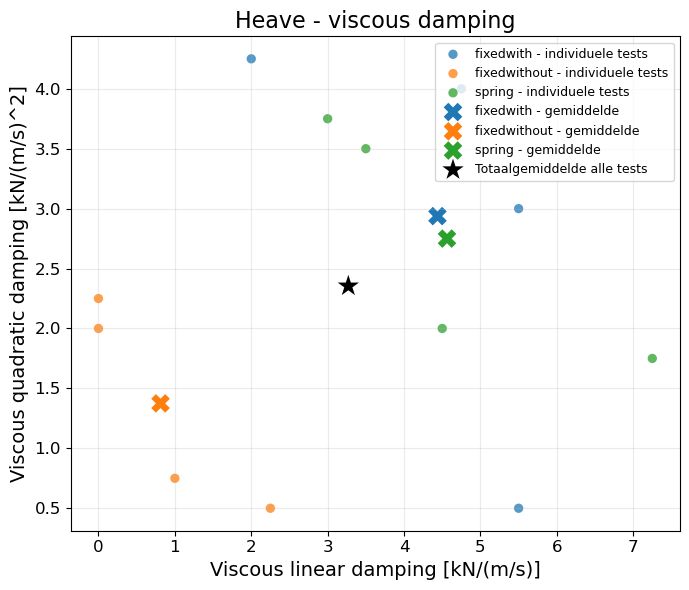

Plot opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\heave_summary\heave_viscous_damping_summary_plot.png


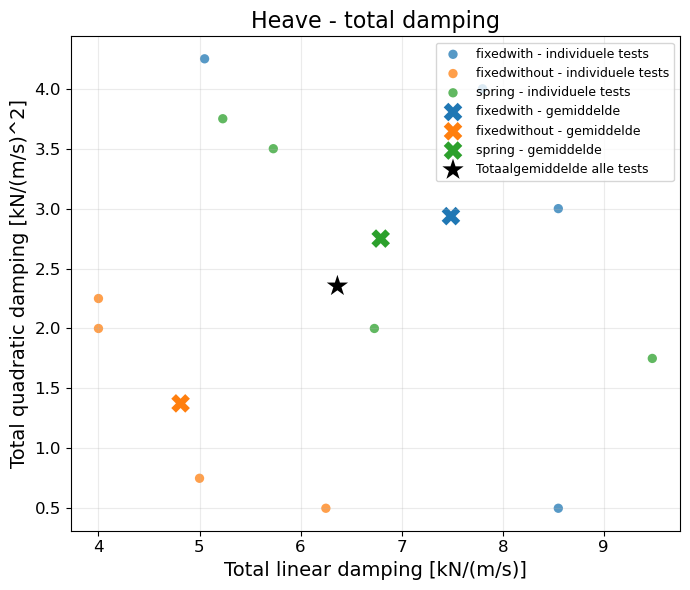

Plot opgeslagen naar:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\heave_summary\heave_total_damping_summary_plot.png


In [9]:
# ============================================================
# Plots: viscous en total damping
# ============================================================
# Assen:
# x = linear damping [kN/(m/s)]
# y = quadratic damping [kN/(m/s)^2]

constructions = list(construction_summary["construction"])
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
construction_colors = {
    construction: color_cycle[i % len(color_cycle)]
    for i, construction in enumerate(constructions)
}


def make_heave_plot(
    x_col,
    y_col,
    mean_x_col,
    mean_y_col,
    global_x,
    global_y,
    title,
    xlabel,
    ylabel,
    save_path,
):
    fig, ax = plt.subplots(figsize=(7, 6))

    # Individuele heave-resultaten per constructie.
    for construction, group in df_valid.groupby("construction"):
        color = construction_colors[construction]
        ax.scatter(
            group[x_col],
            group[y_col],
            s=45,
            alpha=0.75,
            color=color,
            edgecolors="none",
            label=f"{construction} - individuele tests",
        )

    # Gemiddelde per constructie als kruisje in dezelfde kleur als de individuele tests.
    for _, row in construction_summary.iterrows():
        construction = row["construction"]
        color = construction_colors[construction]
        ax.scatter(
            row[mean_x_col],
            row[mean_y_col],
            s=180,
            marker="X",
            color=color,
            edgecolors="none",
            linewidths=0,
            label=f"{construction} - gemiddelde",
        )
        # ax.annotate(
        #     construction,
        #     (row[mean_x_col], row[mean_y_col]),
        #     xytext=(6, 6),
        #     textcoords="offset points",
        #     fontsize=TICK_SIZE,
        # )

    # Totaalgemiddelde over alle individuele tests in zwart.
    ax.scatter(
        global_x,
        global_y,
        s=260,
        marker="*",
        color="black",
        edgecolors="none",
        linewidths=0,
        label="Totaalgemiddelde alle tests",
    )
    # ax.annotate(
    #     "overall",
    #     (global_x, global_y),
    #     xytext=(8, -12),
    #     textcoords="offset points",
    #     fontsize=TICK_SIZE,
    #     fontweight="bold",
    #     color="black",
    # )

    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.set_xlabel(xlabel, fontsize=LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=9)

    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Plot opgeslagen naar:\n{save_path}")


make_heave_plot(
    x_col="linear_damping",
    y_col="quadratic_damping",
    mean_x_col="mean_viscous_linear_damping",
    mean_y_col="mean_viscous_quadratic_damping",
    global_x=selected_global_heave_linear,
    global_y=selected_global_heave_quadratic,
    title="Heave - viscous damping",
    xlabel="Viscous linear damping [kN/(m/s)]",
    ylabel="Viscous quadratic damping [kN/(m/s)^2]",
    save_path=viscous_plot_path,
)

make_heave_plot(
    x_col="total_linear_damping",
    y_col="total_quadratic_damping",
    mean_x_col="mean_total_linear_damping",
    mean_y_col="mean_total_quadratic_damping",
    global_x=selected_global_heave_total_linear,
    global_y=selected_global_heave_total_quadratic,
    title="Heave - total damping",
    xlabel="Total linear damping [kN/(m/s)]",
    ylabel="Total quadratic damping [kN/(m/s)^2]",
    save_path=total_plot_path,
)


## Waarden om handmatig over te nemen

Gebruik de waarden uit `selected_global_heave_linear` en `selected_global_heave_quadratic` als je alleen de viscous heave damping wilt overnemen.

Gebruik `selected_global_heave_total_linear` en `selected_global_heave_total_quadratic` als je de radiation damping al in de lineaire heave damping wilt meenemen.

Gebruik de tabel `construction_summary` als je per constructie een andere heave damping waarde wilt overnemen.


In [8]:
# ============================================================
# Handige print voor overnemen naar 02_calibrate_pitch_roll_damping.ipynb
# ============================================================
print("# Globale viscous heave damping op basis van alle individuele heave tests")
print(f"heave_linear_damping = {selected_global_heave_linear:.6f}")
print(f"heave_quadratic_damping = {selected_global_heave_quadratic:.6f}")

print("\n# Globale total heave damping, inclusief radiation damping")
print(f"heave_total_linear_damping = {selected_global_heave_total_linear:.6f}")
print(f"heave_total_quadratic_damping = {selected_global_heave_total_quadratic:.6f}")

print("\n# Viscous heave damping per constructie")
print("selected_heave_damping = {")
for _, row in construction_summary.iterrows():
    construction = row["construction"]
    lin = row["mean_viscous_linear_damping"]
    quad = row["mean_viscous_quadratic_damping"]
    print(f'    "{construction}": {{"linear": {lin:.6f}, "quadratic": {quad:.6f}}},')
print("}")

print("\n# Total heave damping per constructie, inclusief radiation damping")
print("selected_heave_total_damping = {")
for _, row in construction_summary.iterrows():
    construction = row["construction"]
    lin = row["mean_total_linear_damping"]
    quad = row["mean_total_quadratic_damping"]
    print(f'    "{construction}": {{"linear": {lin:.6f}, "quadratic": {quad:.6f}}},')
print("}")


# Globale viscous heave damping op basis van alle individuele heave tests
heave_linear_damping = 3.270833
heave_quadratic_damping = 2.354167

# Globale total heave damping, inclusief radiation damping
heave_total_linear_damping = 6.364167
heave_total_quadratic_damping = 2.354167

# Viscous heave damping per constructie
selected_heave_damping = {
    "fixedwith": {"linear": 4.437500, "quadratic": 2.937500},
    "fixedwithout": {"linear": 0.812500, "quadratic": 1.375000},
    "spring": {"linear": 4.562500, "quadratic": 2.750000},
}

# Total heave damping per constructie, inclusief radiation damping
selected_heave_total_damping = {
    "fixedwith": {"linear": 7.487500, "quadratic": 2.937500},
    "fixedwithout": {"linear": 4.812500, "quadratic": 1.375000},
    "spring": {"linear": 6.792500, "quadratic": 2.750000},
}
